# Analysis  on  Lazy Investing strategy 

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.dpi'] = 110


CSV_PATH = "sp500_data.csv"
TICKER_LABEL = "S&P 500"
DRAWDOWN_THRESHOLD = -5.0  

df = pd.read_csv(CSV_PATH)
df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
df = df.sort_values('Date').reset_index(drop=True)
df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]

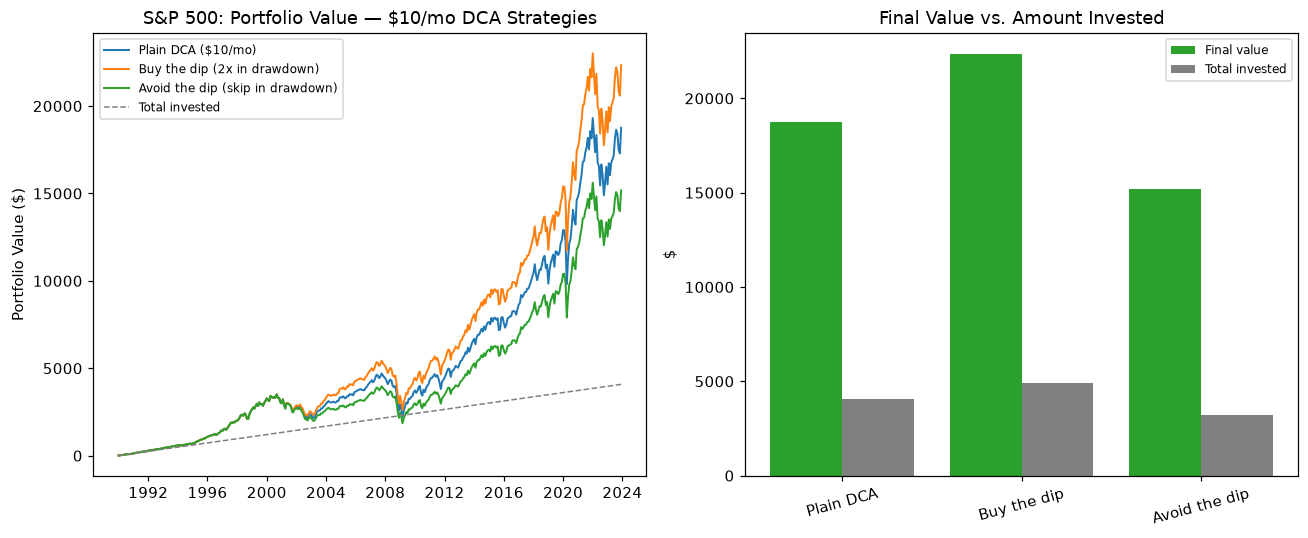

Plain DCA        invested=$4,080  final=$18,757  return=359.7%
Buy the dip      invested=$4,920  final=$22,339  return=354.0%
Avoid the dip    invested=$3,240  final=$15,176  return=368.4%


In [6]:


monthly = df.set_index('Date').resample('MS').first()[['Close']].dropna()
monthly['drawdown_pct'] = (monthly['Close'] - monthly['Close'].cummax()) / monthly['Close'].cummax() * 100

MONTHLY_AMOUNT = 10.0

def simulate_dca(prices, drawdowns, amount_fn):
    shares = 0.0
    invested = 0.0
    history = []
    for price, dd in zip(prices, drawdowns):
        amt = amount_fn(dd)
        shares += amt / price
        invested += amt
        history.append({'value': shares * price, 'invested': invested})
    return pd.DataFrame(history, index=prices.index)

# Strategy A: plain DCA, fixed $10 every month
strat_plain = simulate_dca(monthly['Close'], monthly['drawdown_pct'],
                            lambda dd: MONTHLY_AMOUNT)

# Strategy B: buy the dip — double up when >20% below peak
strat_dip = simulate_dca(monthly['Close'], monthly['drawdown_pct'],
                          lambda dd: MONTHLY_AMOUNT * 2 if dd <= -20 else MONTHLY_AMOUNT)

# Strategy C: avoid the dip — skip investing when >20% below peak
strat_avoid = simulate_dca(monthly['Close'], monthly['drawdown_pct'],
                            lambda dd: 0 if dd <= -20 else MONTHLY_AMOUNT)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(strat_plain.index, strat_plain['value'], label='Plain DCA ($10/mo)', lw=1.3)
axes[0].plot(strat_dip.index, strat_dip['value'], label='Buy the dip (2x in drawdown)', lw=1.3)
axes[0].plot(strat_avoid.index, strat_avoid['value'], label='Avoid the dip (skip in drawdown)', lw=1.3)
axes[0].plot(strat_plain.index, strat_plain['invested'], color='grey', ls='--', lw=1, label='Total invested')
axes[0].set_title(f'{TICKER_LABEL}: Portfolio Value — $10/mo DCA Strategies')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend(fontsize=8)

final_vals = {
    'Plain DCA': strat_plain['value'].iloc[-1],
    'Buy the dip': strat_dip['value'].iloc[-1],
    'Avoid the dip': strat_avoid['value'].iloc[-1],
}
final_invested = {
    'Plain DCA': strat_plain['invested'].iloc[-1],
    'Buy the dip': strat_dip['invested'].iloc[-1],
    'Avoid the dip': strat_avoid['invested'].iloc[-1],
}
x = np.arange(len(final_vals))
axes[1].bar(x - 0.2, final_vals.values(), width=0.4, color='#2ca02c', label='Final value')
axes[1].bar(x + 0.2, final_invested.values(), width=0.4, color='grey', label='Total invested')
axes[1].set_xticks(x)
axes[1].set_xticklabels(final_vals.keys(), rotation=15)
axes[1].set_ylabel('$')
axes[1].set_title('Final Value vs. Amount Invested')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

for name, val in final_vals.items():
    inv = final_invested[name]
    print(f"{name:15s}  invested=${inv:,.0f}  final=${val:,.0f}  return={((val/inv)-1)*100:.1f}%")

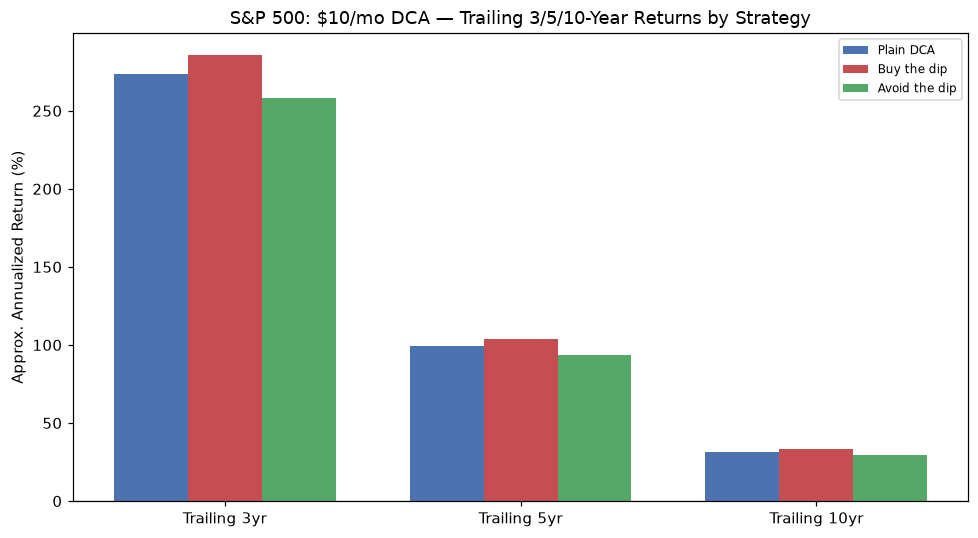

     strategy  years  invested  final_value  cagr_approx
    Plain DCA      3    360.00    18,757.06       273.50
    Plain DCA      5    600.00    18,757.06        99.07
    Plain DCA     10  1,200.00    18,757.06        31.64
  Buy the dip      3    390.00    22,338.50       285.48
  Buy the dip      5    640.00    22,338.50       103.50
  Buy the dip     10  1,240.00    22,338.50        33.53
Avoid the dip      3    330.00    15,175.61       258.27
Avoid the dip      5    560.00    15,175.61        93.46
Avoid the dip     10  1,160.00    15,175.61        29.32


In [7]:
def annualized_return(final_value, invested_series, years):
    total_invested = invested_series.iloc[-1]
    if total_invested <= 0:
        return np.nan
    return ((final_value / total_invested) ** (1 / years) - 1) * 100

def trailing_window_stats(strategy_df, years):
    end_date = strategy_df.index.max()
    start_date = end_date - pd.DateOffset(years=years)
    window = strategy_df[strategy_df.index >= start_date]
    if len(window) < 2:
        return None
    shares_start_value = window['value'].iloc[0]
    invested = window['invested'].iloc[-1] - window['invested'].iloc[0] + (window['invested'].iloc[0])
    final_value = window['value'].iloc[-1]
    total_invested = window['invested'].iloc[-1] - window['invested'].iloc[0]
    if total_invested <= 0:
        return None
    gain_pct = (final_value - window['value'].iloc[0] - total_invested) / total_invested * 100 \
        if window['value'].iloc[0] else (final_value / total_invested - 1) * 100
    cagr = annualized_return(final_value, pd.Series([total_invested]), years)
    return {'years': years, 'invested': total_invested, 'final_value': final_value, 'cagr_approx': cagr}

strategies = {'Plain DCA': strat_plain, 'Buy the dip': strat_dip, 'Avoid the dip': strat_avoid}
windows = [3, 5, 10]

rows = []
for name, sdf in strategies.items():
    for yrs in windows:
        stats = trailing_window_stats(sdf, yrs)
        if stats:
            rows.append({'strategy': name, **stats})

trailing_df = pd.DataFrame(rows)


fig, ax = plt.subplots(figsize=(9, 5))
bar_width = 0.25
x = np.arange(len(windows))
colors = {'Plain DCA': '#4c72b0', 'Buy the dip': '#c44e52', 'Avoid the dip': '#55a868'}

for i, (name, sdf) in enumerate(strategies.items()):
    vals = [trailing_df[(trailing_df['strategy'] == name) & (trailing_df['years'] == y)]['cagr_approx'].values[0]
            if len(trailing_df[(trailing_df['strategy'] == name) & (trailing_df['years'] == y)]) else np.nan
            for y in windows]
    ax.bar(x + (i - 1) * bar_width, vals, width=bar_width, label=name, color=colors[name])

ax.set_xticks(x)
ax.set_xticklabels([f'Trailing {y}yr' for y in windows])
ax.set_ylabel('Approx. Annualized Return (%)')
ax.set_title(f'{TICKER_LABEL}: $10/mo DCA — Trailing 3/5/10-Year Returns by Strategy')
ax.axhline(0, color='grey', lw=0.8)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(trailing_df.round(2).to_string(index=False))

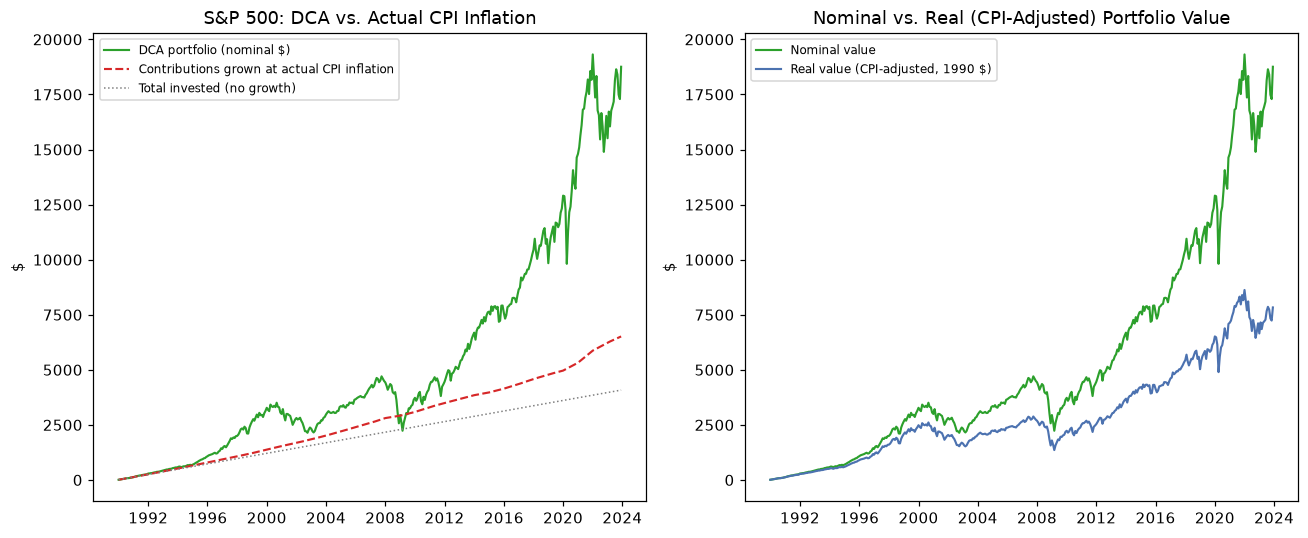

Total invested:                  $4,080
Cumulative inflation over period: 139.5%
Final nominal portfolio value:    $18,757
If only kept pace w/ CPI:         $6,515
Real (CPI-adjusted) value:        $7,832
Market beat inflation by:         187.9%


In [9]:
CPI_PATH = "cpi.csv"
CPI_DATE_COL = "observation_date"
CPI_VALUE_COL = "FPCPITOTLZGUSA"   # annual % inflation

cpi_raw = pd.read_csv(CPI_PATH)
cpi_raw[CPI_DATE_COL] = pd.to_datetime(cpi_raw[CPI_DATE_COL])
cpi_raw = cpi_raw.sort_values(CPI_DATE_COL).reset_index(drop=True)


cpi_raw['cpi_index'] = 100 * (1 + cpi_raw[CPI_VALUE_COL] / 100).cumprod()
cpi_raw['cpi_index'] = cpi_raw['cpi_index'] / cpi_raw['cpi_index'].iloc[0] * 100


annual_cpi = cpi_raw.set_index(CPI_DATE_COL)['cpi_index']
full_range = pd.date_range(annual_cpi.index.min(),
                            annual_cpi.index.max() + pd.DateOffset(years=1) - pd.DateOffset(months=1),
                            freq='MS')
monthly_cpi = annual_cpi.reindex(annual_cpi.index.union(full_range)).sort_index()
monthly_cpi = monthly_cpi.interpolate(method='time').reindex(full_range).ffill().bfill()


cpi_aligned = monthly_cpi.reindex(strat_plain.index, method='ffill').bfill()
cpi_factor = cpi_aligned / cpi_aligned.iloc[0]

def simulate_cpi_baseline(invested_series, cpi_index):
    balance = 0.0
    history = []
    monthly_contribution = invested_series.diff().fillna(invested_series.iloc[0])
    prev_cpi = cpi_index.iloc[0]
    for contrib, cur_cpi in zip(monthly_contribution, cpi_index):
        balance = balance * (cur_cpi / prev_cpi) + contrib
        prev_cpi = cur_cpi
        history.append(balance)
    return pd.Series(history, index=invested_series.index)

cpi_baseline = simulate_cpi_baseline(strat_plain['invested'], cpi_aligned)
real_value = strat_plain['value'] / cpi_factor  # in start-date (1990) dollars

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(strat_plain.index, strat_plain['value'], label='DCA portfolio (nominal $)', lw=1.4, color='#2ca02c')
axes[0].plot(strat_plain.index, cpi_baseline, label='Contributions grown at actual CPI inflation',
             lw=1.4, color='#d62728', ls='--')
axes[0].plot(strat_plain.index, strat_plain['invested'], label='Total invested (no growth)', lw=1, color='grey', ls=':')
axes[0].set_title(f'{TICKER_LABEL}: DCA vs. Actual CPI Inflation')
axes[0].set_ylabel('$')
axes[0].legend(fontsize=8)

axes[1].plot(strat_plain.index, strat_plain['value'], label='Nominal value', lw=1.4, color='#2ca02c')
axes[1].plot(strat_plain.index, real_value, label='Real value (CPI-adjusted, 1990 $)', lw=1.4, color='#4c72b0')
axes[1].set_title('Nominal vs. Real (CPI-Adjusted) Portfolio Value')
axes[1].set_ylabel('$')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

total_invested = strat_plain['invested'].iloc[-1]
final_nominal = strat_plain['value'].iloc[-1]
final_cpi_baseline = cpi_baseline.iloc[-1]
final_real = real_value.iloc[-1]
cumulative_inflation_pct = (cpi_factor.iloc[-1] - 1) * 100

print(f"Total invested:                  ${total_invested:,.0f}")
print(f"Cumulative inflation over period: {cumulative_inflation_pct:.1f}%")
print(f"Final nominal portfolio value:    ${final_nominal:,.0f}")
print(f"If only kept pace w/ CPI:         ${final_cpi_baseline:,.0f}")
print(f"Real (CPI-adjusted) value:        ${final_real:,.0f}")
print(f"Market beat inflation by:         {((final_nominal/final_cpi_baseline)-1)*100:.1f}%")

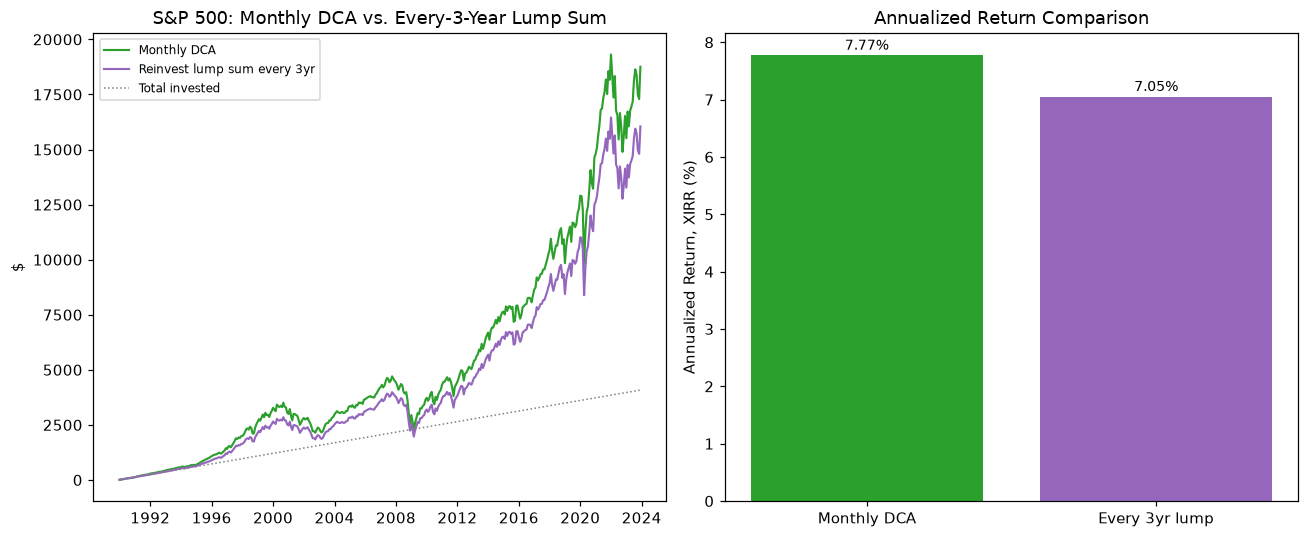

Monthly DCA final value:        $18,757   XIRR: 7.77%
Every-3yr lump final value:     $16,050   XIRR: 7.05%


In [12]:
from scipy.optimize import brentq

def simulate_lump_every_n_years(prices, amount, n_years=3):
    """Same $10/month contribution, but held in cash and invested as one
    lump sum every n_years instead of monthly."""
    shares = 0.0
    invested = 0.0
    cash_bucket = 0.0
    history = []
    months_per_cycle = n_years * 12
    for i, price in enumerate(prices):
        cash_bucket += amount
        invested += amount
        if (i + 1) % months_per_cycle == 0:   # anniversary -> invest the pooled cash
            shares += cash_bucket / price
            cash_bucket = 0.0
        history.append({'value': shares * price + cash_bucket, 'invested': invested})
    if cash_bucket > 0:  # invest whatever's left over at the very end
        history[-1]['value'] = shares * prices.iloc[-1] + cash_bucket
    return pd.DataFrame(history, index=prices.index)

strat_lump3 = simulate_lump_every_n_years(monthly['Close'], MONTHLY_AMOUNT, n_years=3)


def xirr(cashflows, dates):
    dates = pd.to_datetime(dates)
    t0 = dates[0]
    years = np.array([(d - t0).days / 365.25 for d in dates])
    npv = lambda rate: np.sum(np.array(cashflows) / (1 + rate) ** years)
    return brentq(npv, -0.99, 10)

def strategy_xirr(strategy_df, monthly_amount):
    dates = list(strategy_df.index)
    cashflows = [-monthly_amount] * len(dates)     # money going in, every month
    cashflows[-1] += strategy_df['value'].iloc[-1]  # portfolio cashed out at the end
    return xirr(cashflows, dates) * 100

dca_xirr = strategy_xirr(strat_plain, MONTHLY_AMOUNT)
lump3_xirr = strategy_xirr(strat_lump3, MONTHLY_AMOUNT)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(strat_plain.index, strat_plain['value'], label='Monthly DCA', lw=1.4, color='#2ca02c')
axes[0].plot(strat_lump3.index, strat_lump3['value'], label='Reinvest lump sum every 3yr', lw=1.4, color='#9467bd')
axes[0].plot(strat_plain.index, strat_plain['invested'], label='Total invested', lw=1, color='grey', ls=':')
axes[0].set_title(f'{TICKER_LABEL}: Monthly DCA vs. Every-3-Year Lump Sum')
axes[0].set_ylabel('$')
axes[0].legend(fontsize=8)

axes[1].bar(['Monthly DCA', 'Every 3yr lump'], [dca_xirr, lump3_xirr],
            color=['#2ca02c', '#9467bd'])
axes[1].set_ylabel('Annualized Return, XIRR (%)')
axes[1].set_title('Annualized Return Comparison')
for i, v in enumerate([dca_xirr, lump3_xirr]):
    axes[1].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Monthly DCA final value:        ${strat_plain['value'].iloc[-1]:,.0f}   XIRR: {dca_xirr:.2f}%")
print(f"Every-3yr lump final value:     ${strat_lump3['value'].iloc[-1]:,.0f}   XIRR: {lump3_xirr:.2f}%")